Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 2.0.2
*   scipy version: 1.16.1
*   pyclustering version: 0.10.1.2

In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster

!pip install pyclustering

import warnings
np.warnings = warnings # Fix for compatibility issue with pyclustering

from pyclustering.cluster.kmeans import kmeans
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from pyclustering.utils.metric import type_metric, distance_metric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=bc2d720baf98c3cc1a07792520d616e3794e7d0d6ee7f106c624544ce582444a
  Stored in directory: /root/.cache/pip/wheels/9f/99/15/e881f46a92690ae77c2e3b255b89ea45d3a867b1b6c2ab3ba9
Successfully built pyclustering


In [ ]:
# Import data from dropbox
!wget -O scotchChar.csv https://www.dropbox.com/scl/fi/ezlo7pundle63l8zjgwkn/scotchChar.csv?rlkey=3uvix57rxcmm3iwsxjqa88coy&dl=0

# Import
df = pd.read_csv("scotchChar.csv")
print(df.head())

name_col = "NAME"
X = df.iloc[:, 2:70].copy().astype(int)
names = df[name_col].astype(str).tolist()

# There's a typo. Change "Ardberg" -> "Ardbeg"
names = ["Ardbeg" if n == "Ardberg" else n for n in names]
df[name_col] = names

--2025-08-13 23:00:50--  https://www.dropbox.com/scl/fi/ezlo7pundle63l8zjgwkn/scotchChar.csv?rlkey=3uvix57rxcmm3iwsxjqa88coy
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc215ddb39d261692fc0bcb88dd7.dl.dropboxusercontent.com/cd/0/inline/CvXMLaeZ5eWB0n7DHV17Q8_WTyXeRFgpOi5fnpWmCgbFwJYQtFUt2DH724oZRu7N8Qriv1IHHDQ-T044zLCTCuXpVW8-VehdLfq57tvnfOFIWCD4gDAa9br_JKWqATIjUpOrVPUn1iNPKffCVUmDtubb/file# [following]
--2025-08-13 23:00:51--  https://uc215ddb39d261692fc0bcb88dd7.dl.dropboxusercontent.com/cd/0/inline/CvXMLaeZ5eWB0n7DHV17Q8_WTyXeRFgpOi5fnpWmCgbFwJYQtFUt2DH724oZRu7N8Qriv1IHHDQ-T044zLCTCuXpVW8-VehdLfq57tvnfOFIWCD4gDAa9br_JKWqATIjUpOrVPUn1iNPKffCVUmDtubb/file
Resolving uc215ddb39d261692fc0bcb88dd7.dl.dropboxusercontent.com (uc215ddb39d261692fc0bcb88dd7.dl.dropboxusercontent.com)... 162.125.5.15, 2620

In [ ]:
# Compute Jaccard distances between all observations
D = pairwise_distances(X.values, metric="jaccard")

# Get distances to Ardbeg
ard_idx = df[name_col].tolist().index("Ardbeg")

# Extract the row of distances from Ardbeg to all others
D_ardbeg = D[ard_idx, :]

# Put it in a Series with names for readability
dist_from_ardbeg = pd.Series(D_ardbeg, index=names)

print(dist_from_ardbeg.sort_values().head(10))


Ardbeg             0.000000
Bowmore            0.461538
Pulteney           0.647059
Inchgower          0.647059
Bunnahabhain       0.666667
Glenury Royal      0.666667
North Port         0.687500
Glen  Albyn        0.705882
Saint Magdalene    0.705882
Dufftown           0.714286
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [ ]:
# A little function to pull out names of Whiskys in a target cluster
def list_cluster_mates(cluster_labels, target_name, names):
    t = names.index(target_name)
    c = cluster_labels[t]
    mates = [names[i] for i in np.where(cluster_labels == c)[0]]
    return c, mates

# Help summarize clusters
def print_top_features_by_cluster(X, labels, topn=5, title="Top features per cluster"):
    unique_clusters = np.unique(labels)
    print(f"\n=== {title} ===")
    for c in unique_clusters:
        mask = (labels == c)
        means = X.loc[mask].mean().sort_values(ascending=False)
        top = means.head(topn)
        print(f"\nCluster {c} (n={mask.sum()})")
        for feat, m in top.items():
            print(f"  {feat}: {m:.3f}")


In [ ]:
# Using pyclustering to do k-means with Jaccard. Should probably just do Euclidean,
# but want to illustrate.

def jaccard_distance(u, v):
    """Jaccard distance for binary 0/1 vectors u, v."""
    u = np.asarray(u, dtype=bool)
    v = np.asarray(v, dtype=bool)
    inter = np.logical_and(u, v).sum()
    union = np.logical_or(u, v).sum()
    if union == 0:
        return 0.0
    return 1.0 - inter / union

_kmeans_cache = {}  # key: k, value: (labels, centers, obj)

def kmeans_pyclustering_jaccard(Xbin, k, n_init=10, max_iter=200, seed=123):
    if k in _kmeans_cache:
        return _kmeans_cache[k]

    data = Xbin.values.tolist()
    metric = distance_metric(type_metric.USER_DEFINED, func=jaccard_distance)

    rng = np.random.default_rng(seed)
    random.seed(seed)

    best_labels = None
    best_centers = None
    best_obj = np.inf

    for _ in range(n_init):
        # k-means++ initialization under Jaccard
        init_centers = kmeans_plusplus_initializer(data, k, metric=metric).initialize()

        algo = kmeans(data, init_centers, metric=metric, itermax=max_iter, tolerance=1e-6)
        algo.process()

        clusters = algo.get_clusters()
        centers = algo.get_centers()

        # Build labels and compute objective
        labels = np.empty(len(data), dtype=int)
        obj = 0.0
        for cid, inds in enumerate(clusters):
            c = centers[cid]
            for i in inds:
                labels[i] = cid
                obj += jaccard_distance(data[i], c)

        if obj < best_obj:
            best_obj = obj
            best_labels = labels.copy()
            best_centers = [c.copy() for c in centers]

    _kmeans_cache[k] = (best_labels, best_centers, best_obj)
    return _kmeans_cache[k]

Running K=2
Running K=3
Running K=4
Running K=5
Running K=6
Running K=7
Running K=8
Running K=9
Running K=10
Running K=11
Running K=12
Running K=13
Running K=14
Running K=15
Running K=16
Running K=17
Running K=18
Running K=19
Running K=20
     K  objective
0    2  86.297619
1    3  84.829365
2    4  83.155617
3    5  82.069067
4    6  81.689917
5    7  79.493416
6    8  78.390656
7    9  77.406367
8   10  75.566148
9   11  74.527471
10  12  73.491420
11  13  72.382661
12  14  71.493623
13  15  70.369787
14  16  69.395651
15  17  68.338357
16  18  67.253429
17  19  66.533005
18  20  64.608208


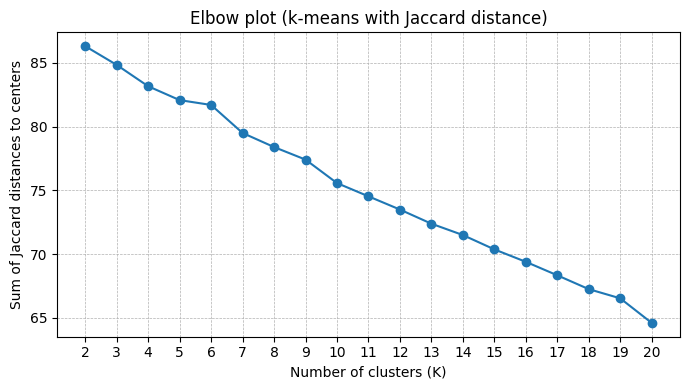

In [ ]:
Ks = range(2, 21)
objs = []

n_init = 100      # many random starts. Takes a while, could reduce or parallelize.
seed   = 9202015  # reproducible
max_iter = 200

n = len(X)

for K in Ks:
    print(f"Running K={K}", flush=True)
    labels, centers, obj = kmeans_pyclustering_jaccard(
        X, k=K, n_init=n_init, max_iter=max_iter, seed=seed
    )
    objs.append(obj)

elbow_df = pd.DataFrame({"K": list(Ks), "objective": objs})
print(elbow_df)

# --- elbow plot (objective vs K) ---
plt.figure(figsize=(7,4))
plt.plot(elbow_df["K"], elbow_df["objective"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Jaccard distances to centers")
plt.title("Elbow plot (k-means with Jaccard distance)")
plt.xticks(list(Ks))
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
for k in [5, 10, 20]:
    labels, centers, obj = _kmeans_cache[k]
    c_id, mates = list_cluster_mates(labels, "Ardbeg", names)
    print(f"Ardbeg cluster ID: {c_id}")
    print("Cluster members:")
    print(", ".join(mates))

Ardbeg cluster ID: 4
Cluster members:
Ardbeg, Benriach, Benrinnes, Bowmore, Convalmore, Craigellachie, Dailuaine, Glencadam, Glen Deveron, Glen Garioch, Glenlossie, Glen Mhor, Glen Ordie, Glenrothes, Glen Scotia, Imperial, Inchgower, Jura, Linkwood, Lochnagar, North Port, Oban, Pulteney, Springbank, Tobermory
Ardbeg cluster ID: 7
Cluster members:
Ardbeg, Bowmore, Brackla, Coleburn, Glenlivet, Oban, Port Ellen, Pulteney, Scapa
Ardbeg cluster ID: 4
Cluster members:
Ardbeg, Inchgower, Oban, Pulteney, Springbank


In [ ]:
labels_k10, centers_k10, obj_k10 = _kmeans_cache[10]
print_top_features_by_cluster(X, labels_k10, topn=5, title="Top 5 features per cluster (k=10)")


=== Top 5 features per cluster (k=10) ===

Cluster 0 (n=9)
  body.light: 0.778
  pal.sweet: 0.667
  color.p.gold: 0.556
  nose.FRESH: 0.556
  body.med: 0.444

Cluster 1 (n=11)
  pal.sweet: 0.636
  body.light: 0.636
  body.med: 0.636
  nose.PEAT: 0.636
  fin.dry: 0.545

Cluster 2 (n=8)
  pal.sweet: 0.750
  nose.PEAT: 0.750
  body.full: 0.625
  pal.smoke: 0.625
  fin.big: 0.500

Cluster 3 (n=12)
  pal.fruit: 0.667
  body.light: 0.667
  pal.sweet: 0.583
  pal.grass: 0.583
  fin.light: 0.500

Cluster 4 (n=12)
  pal.sweet: 0.750
  nose.AROMA: 0.583
  body.smooth: 0.583
  body.med: 0.500
  fin.smooth: 0.500

Cluster 5 (n=14)
  pal.sweet: 0.857
  body.med: 0.786
  pal.dry: 0.643
  nose.DRY: 0.571
  pal.smoke: 0.571

Cluster 6 (n=10)
  pal.sweet: 0.800
  body.light: 0.800
  nose.SWEET: 0.600
  body.smooth: 0.600
  nose.AROMA: 0.600

Cluster 7 (n=9)
  pal.sweet: 0.889
  body.med: 0.778
  nose.SEA: 0.667
  nose.PEAT: 0.556
  body.light: 0.556

Cluster 8 (n=11)
  body.med: 0.909
  pal.sweet: 0.6

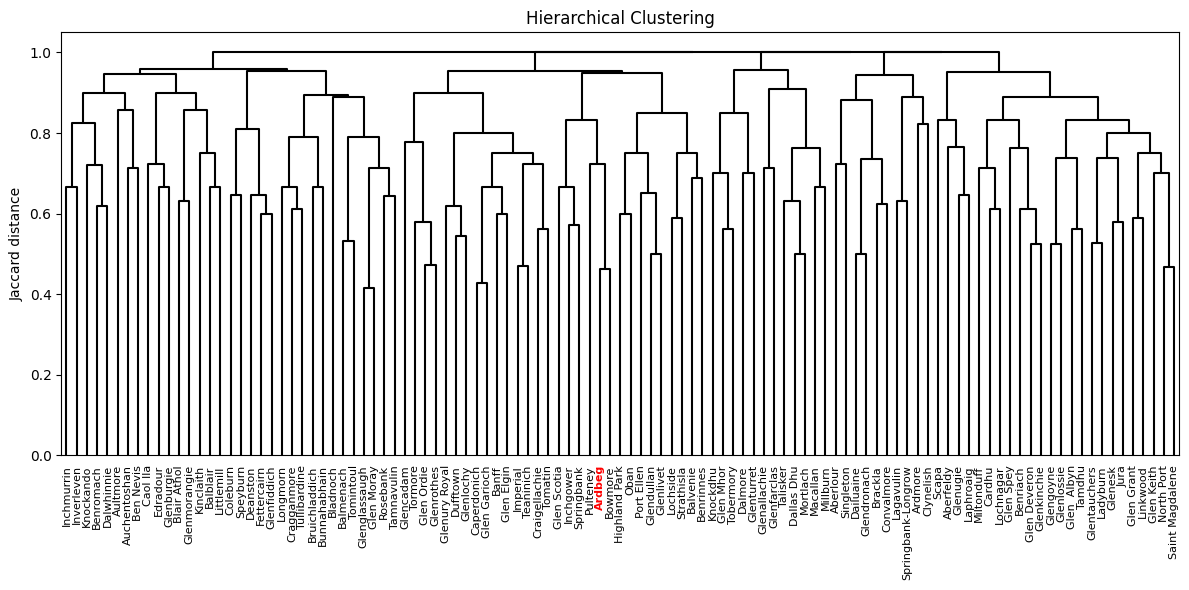

In [ ]:
# -------------------------------
# Agglomerative hierarchical clustering on Jaccard + dendrogram with Ardbeg highlighted
# -------------------------------
# For SciPy’s linkage, provide condensed distances
D_condensed = squareform(D, checks=False)
Z = linkage(D_condensed, method="complete")

plt.figure(figsize=(12, 6))
d = dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8, link_color_func=lambda k: 'k')
plt.title("Hierarchical Clustering")
plt.ylabel("Jaccard distance")

# Highlight Ardbeg in red/bold
ax = plt.gca()
for tick in ax.get_xmajorticklabels():
    if tick.get_text() == "Ardbeg":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.tight_layout()
plt.show()


In [ ]:
# Agglomerative clusters for k = 5, 10, 20
for k in [5, 10, 20]:
    agg = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="complete")
    labs = agg.fit_predict(D)
    c_id, mates = list_cluster_mates(labs, "Ardbeg", names)
    print(f"\n[Agglomerative, k={k}] Ardbeg cluster ID: {c_id}")
    print("Cluster members:")
    print(", ".join(mates))


[Agglomerative, k=5] Ardbeg cluster ID: 2
Cluster members:
Ardbeg, Balvenie, Banff, Benrinnes, Bowmore, Caperdonich, Craigellachie, Dufftown, Glencadam, Glendullan, Glen Elgin, Glen Garioch, Glenlivet, Glenlochy, Glen Ordie, Glenrothes, Glen Scotia, Glenury Royal, Highland Park, Imperial, Inchgower, Lochside, Oban, Port Ellen, Pulteney, Springbank, Strathisla, Teaninich, Tomatin, Tormore

[Agglomerative, k=10] Ardbeg cluster ID: 0
Cluster members:
Ardbeg, Balvenie, Benrinnes, Bowmore, Glendullan, Glenlivet, Glen Scotia, Highland Park, Inchgower, Lochside, Oban, Port Ellen, Pulteney, Springbank, Strathisla

[Agglomerative, k=20] Ardbeg cluster ID: 4
Cluster members:
Ardbeg, Bowmore, Glen Scotia, Inchgower, Pulteney, Springbank


In [ ]:
agg10 = AgglomerativeClustering(n_clusters=10, metric="precomputed", linkage="complete")
labs10 = agg10.fit_predict(D)
print_top_features_by_cluster(X, labs10, topn=5, title="Top 5 features per cluster, Hierarchical (k=10)")


=== Top 5 features per cluster, Hierarchical (k=10) ===

Cluster 0 (n=15)
  body.med: 0.933
  pal.sweet: 0.800
  body.smooth: 0.667
  color.amber: 0.600
  pal.dry: 0.600

Cluster 1 (n=10)
  body.full: 0.800
  body.med: 0.700
  pal.sweet: 0.700
  nose.SWEET: 0.600
  nose.SHERRY: 0.500

Cluster 2 (n=16)
  pal.sweet: 0.750
  body.light: 0.688
  pal.spice: 0.688
  nose.PEAT: 0.500
  pal.fruit: 0.500

Cluster 3 (n=15)
  body.med: 0.933
  nose.PEAT: 0.933
  pal.sweet: 0.867
  color.f.gold: 0.867
  nose.AROMA: 0.667

Cluster 4 (n=20)
  pal.sweet: 0.950
  body.med: 0.800
  body.light: 0.800
  fin.dry: 0.800
  nose.DRY: 0.550

Cluster 5 (n=7)
  fin.long: 0.857
  nose.SWEET: 0.857
  nose.RICH: 0.714
  body.full: 0.714
  pal.sweet: 0.714

Cluster 6 (n=5)
  body.soft: 1.000
  nose.SWEET: 1.000
  pal.smoke: 0.800
  pal.fruit: 0.800
  fin.long: 0.600

Cluster 7 (n=12)
  body.smooth: 0.833
  body.light: 0.833
  nose.GRASS: 0.750
  body.firm: 0.667
  pal.grass: 0.667

Cluster 8 (n=5)
  pal.fruit: 1.0

Distance cutoff for 20 clusters: 0.8889


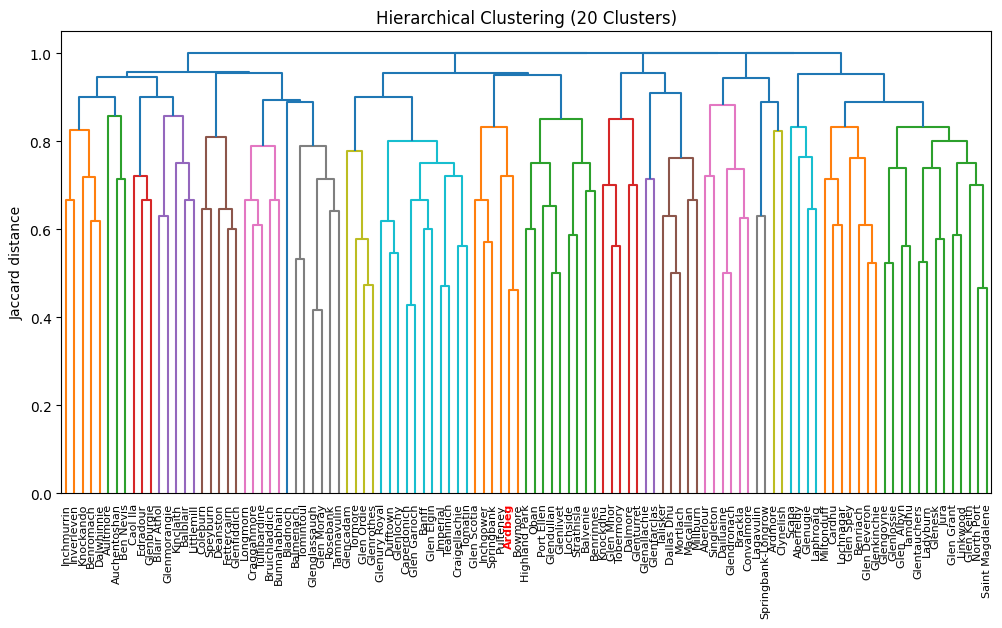

In [ ]:
K = 20
clusters = fcluster(Z, t=K, criterion="maxclust")

# To find the distance threshold that yields exactly K clusters:
# Sort the distances where merges occur (Z[:, 2] are the linkage distances)
# For K clusters, the cutoff is just below the (n - K)-th largest merge distance.
n_samples = Z.shape[0] + 1
cut_index = n_samples - K
distance_cutoff = Z[cut_index - 1, 2]

print(f"Distance cutoff for {K} clusters: {distance_cutoff:.4f}")

plt.figure(figsize=(12, 6))
d = dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8, color_threshold=distance_cutoff)
plt.title("Hierarchical Clustering (20 Clusters)")
plt.ylabel("Jaccard distance")

# Highlight Ardbeg in red/bold
ax = plt.gca()
for tick in ax.get_xmajorticklabels():
    if tick.get_text() == "Ardbeg":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.show()

Distance cutoff for 10 clusters: 0.9500


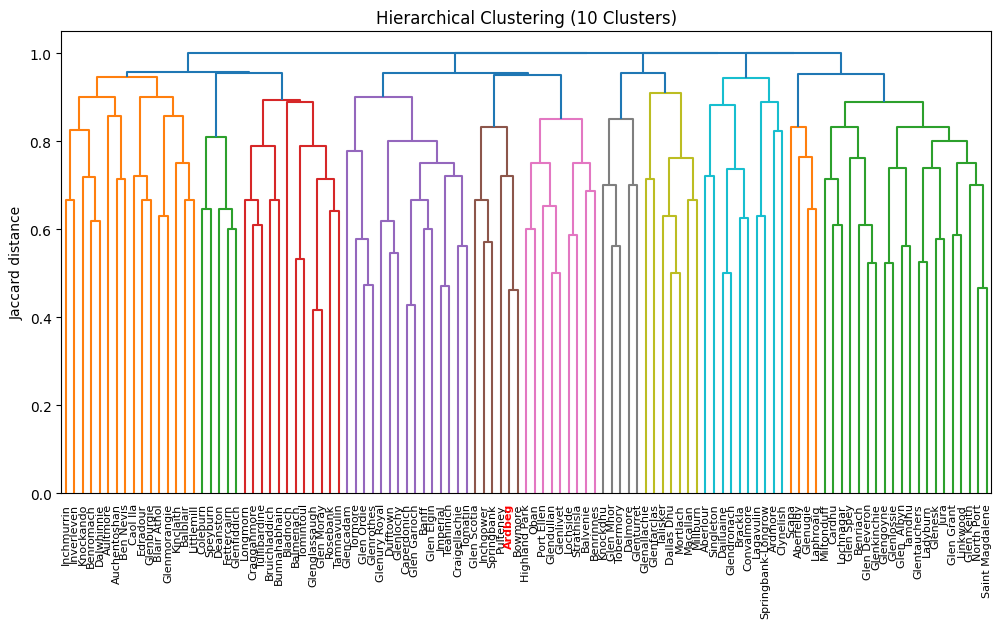

In [ ]:
K = 10
clusters = fcluster(Z, t=K, criterion="maxclust")

# To find the distance threshold that yields exactly K clusters:
# Sort the distances where merges occur (Z[:, 2] are the linkage distances)
# For K clusters, the cutoff is just below the (n - K)-th largest merge distance.
n_samples = Z.shape[0] + 1
cut_index = n_samples - K
distance_cutoff = Z[cut_index - 1, 2]

print(f"Distance cutoff for {K} clusters: {distance_cutoff:.4f}")

plt.figure(figsize=(12, 6))
d = dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8, color_threshold=distance_cutoff)
plt.title("Hierarchical Clustering (10 Clusters)")
plt.ylabel("Jaccard distance")

# Highlight Ardbeg in red/bold
ax = plt.gca()
for tick in ax.get_xmajorticklabels():
    if tick.get_text() == "Ardbeg":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.show()

Distance cutoff for 5 clusters: 0.9583


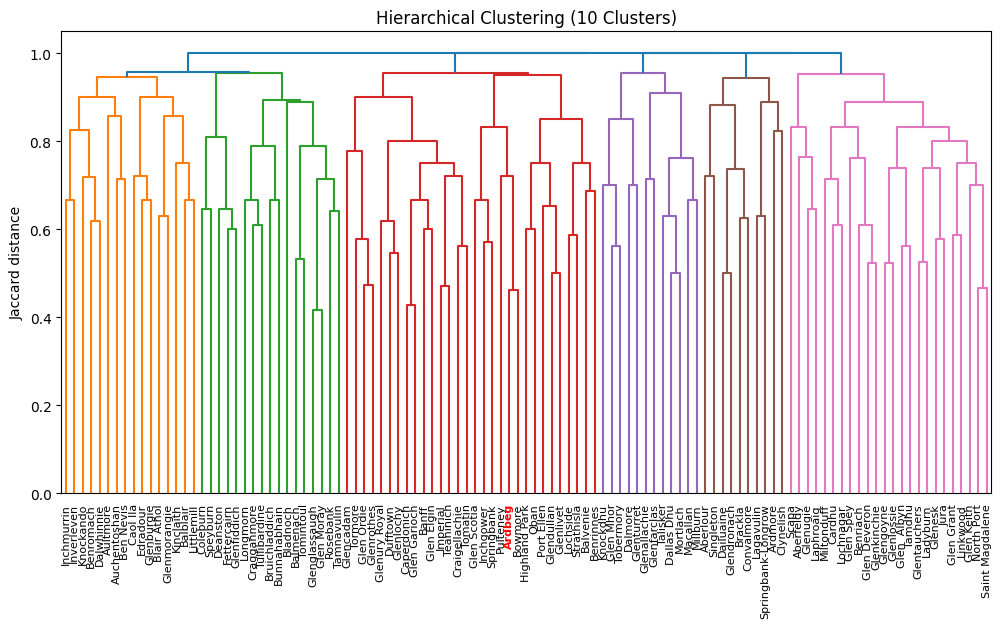

In [ ]:
K = 5
clusters = fcluster(Z, t=K, criterion="maxclust")

# To find the distance threshold that yields exactly K clusters:
# Sort the distances where merges occur (Z[:, 2] are the linkage distances)
# For K clusters, the cutoff is just below the (n - K)-th largest merge distance.
n_samples = Z.shape[0] + 1
cut_index = n_samples - K
distance_cutoff = Z[cut_index - 1, 2]

print(f"Distance cutoff for {K} clusters: {distance_cutoff:.4f}")

plt.figure(figsize=(12, 6))
d = dendrogram(Z, labels=names, leaf_rotation=90, leaf_font_size=8, color_threshold=distance_cutoff)
plt.title("Hierarchical Clustering (10 Clusters)")
plt.ylabel("Jaccard distance")

# Highlight Ardbeg in red/bold
ax = plt.gca()
for tick in ax.get_xmajorticklabels():
    if tick.get_text() == "Ardbeg":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.show()